# Gradient Boosting Regression: Student Performance

### How accurately can Gradient Boosting Regression predict a student's final grade (G3) using demographic, social, behavoural and educational characteristics, omitting information about previous grades (G1 and G2) and previous failures?

## Variable Definitions

The dataset uses abbreviated variable names. The following definitions are provided to aid interpretation of the analysis.

| Variable | Meaning |
|---|---|
| `G3` | Final grade (target variable) |
| `G1` | First-period grade |
| `G2` | Second-period grade |
| `failures` | Number of previous class failures |
| `Medu` | Mother's education level |
| `Fedu` | Father's education level |
| `traveltime` | Home-to-school travel time |
| `studytime` | Weekly study time |
| `famrel` | Quality of family relationships |
| `freetime` | Free time after school |
| `goout` | Going out with friends |
| `Dalc` | Workday alcohol consumption |
| `Walc` | Weekend alcohol consumption |
| `health` | Current health status |
| `absences` | Number of school absences |
| `higher` | Whether the student wants to pursue higher education |
| `schoolsup` | Extra educational support from school |
| `famsup` | Educational support from family |
| `paid` | Extra paid classes |
| `activities` | Extra-curricular activities |
| `internet` | Internet access at home |
| `romantic` | Whether the student is in a romantic relationship |

Dataset successfully loaded.

Dataset dimensions:
(649, 33)

First five rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]

DATASET I

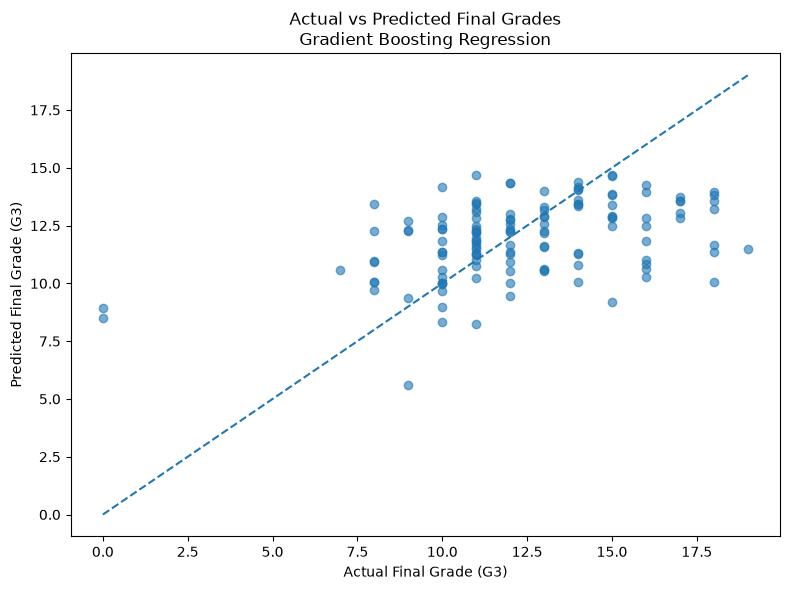

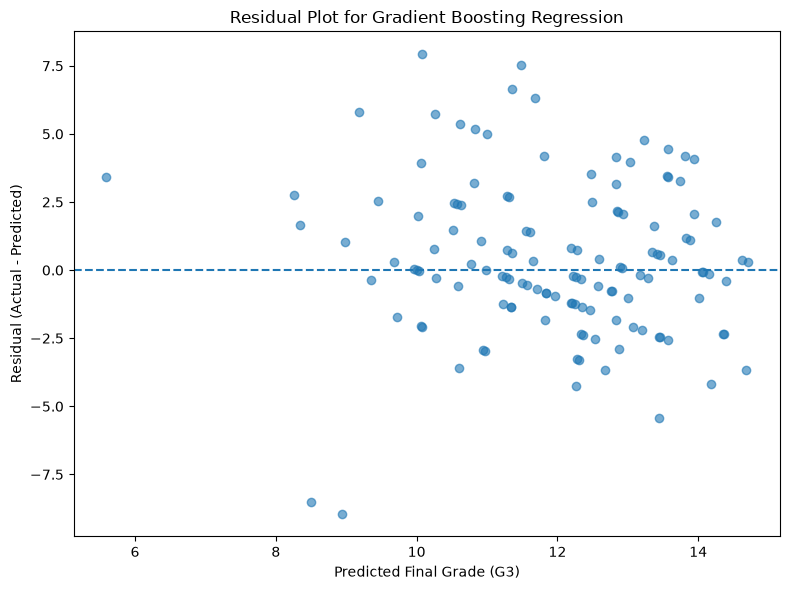

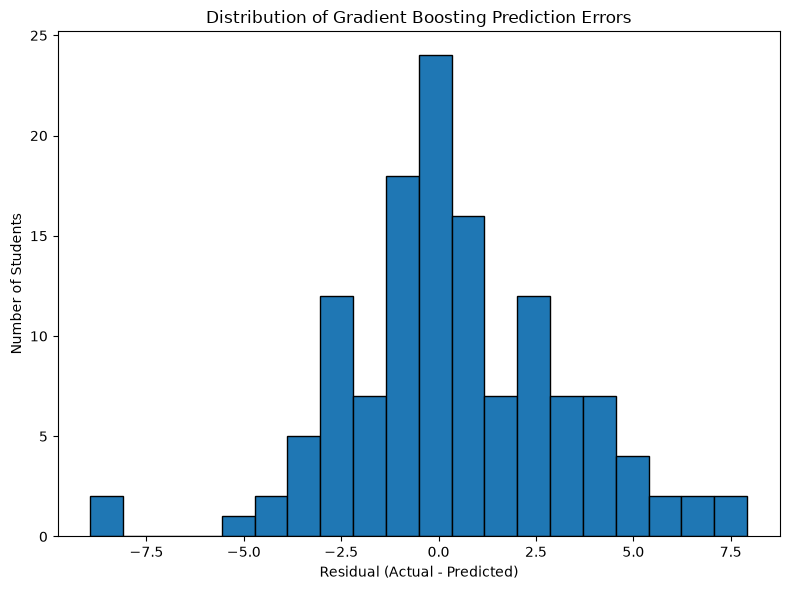


TOP 15 MOST IMPORTANT FEATURES
     Feature  Importance
   higher_no    0.074018
   school_MS    0.072660
   school_GP    0.071623
        Dalc    0.070533
         age    0.069056
    absences    0.054180
  higher_yes    0.053983
        Walc    0.051425
        Fedu    0.051093
      health    0.045048
       goout    0.040523
   studytime    0.039609
reason_other    0.032628
        Medu    0.032309
      famrel    0.024632


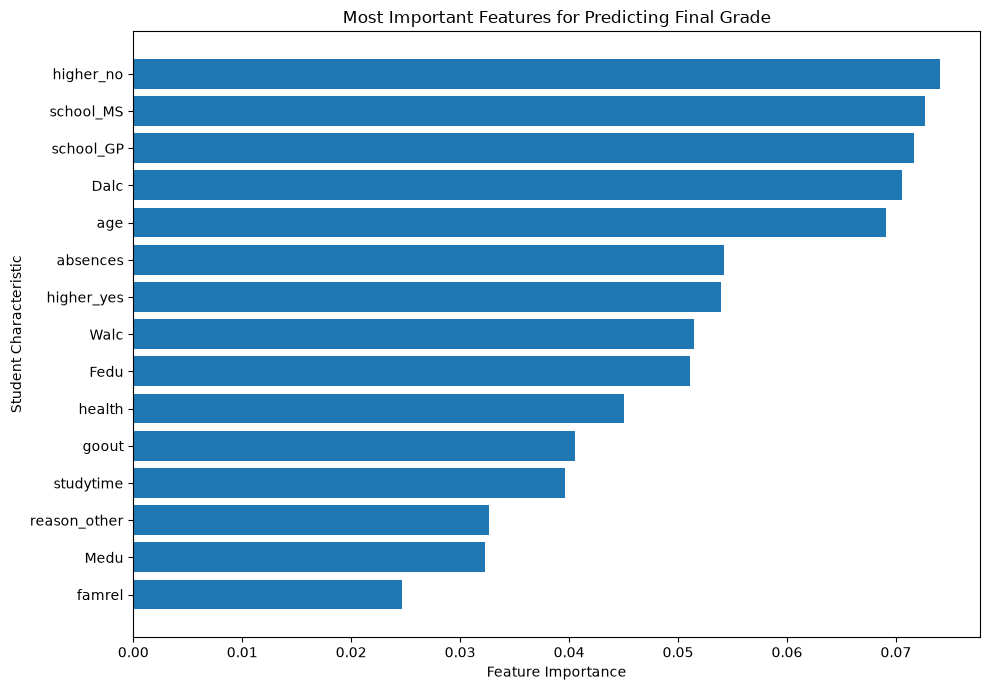


BASELINE VS GRADIENT BOOSTING

BASELINE MODEL
----------------
MAE:  2.395
RMSE: 3.173
R²:   -0.032

GRADIENT BOOSTING
----------------
MAE:  2.147
RMSE: 2.871
R²:   0.155

Improvement over baseline:
MAE improvement: 10.35%
RMSE improvement: 9.50%

FINAL SUMMARY

Research question:

How accurately can Gradient Boosting Regression predict a
student's final grade (G3) using demographic, social,
behavioural and educational characteristics, without using
G1, G2 or previous failures?


Variables deliberately excluded:

G1       - first-period grade
G2       - second-period grade
failures - previous class failures


Gradient Boosting performance:

MAE  = 2.147
RMSE = 2.871
R²   = 0.155


Baseline performance:

MAE  = 2.395
RMSE = 3.173
R²   = -0.032


The feature-importance analysis shows which of the remaining
student characteristics were most useful to the Gradient
Boosting model when predicting final grades.

Feature importance represents predictive usefulness and
should NOT be interpret

In [9]:
# ============================================================
# GRADIENT BOOSTING REGRESSION
# Student Performance in Secondary Education
#
# Research question:
# How accurately can Gradient Boosting Regression predict a
# student's final grade (G3) using demographic, social,
# behavioural and educational characteristics, WITHOUT using
# previous grades (G1 and G2) or previous failures?
# ============================================================




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)






df = pd.read_csv("student.csv", sep=";")

print("Dataset successfully loaded.")

print("\nDataset dimensions:")
print(df.shape)

print("\nFirst five rows:")
print(df.head())



#  EXPLORE THE DATASET


print("\n================================")
print("DATASET INFORMATION")
print("================================")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicated rows:")
print(df.duplicated().sum())

print("\nSummary statistics:")
print(df.describe())



# REMOVE DUPLICATE ROWS


df = df.drop_duplicates()

print("\nDataset dimensions after removing duplicates:")
print(df.shape)






# G3 is the student's final grade.
# This is the variable that we want the model to predict.

target = "G3"



#  CREATE X (PREDICTORS) AND y (TARGET)


# We deliberately exclude:
#
# G1       = first-period grade
# G2       = second-period grade
# failures = number of previous class failures
#
# We are excluding these because we want to investigate whether
# final performance can be predicted WITHOUT giving the model
# direct information about previous academic performance.

features_to_remove = [
    "G1",
    "G2",
    "G3",
    "failures"
]

X = df.drop(columns=features_to_remove)

y = df[target]


print("\n================================")
print("MODEL SETUP")
print("================================")

print("\nTarget variable:")
print(target)

print("\nExcluded variables:")
print(features_to_remove)

print("\nVariables used to make predictions:")
print(X.columns.tolist())

print("\nNumber of predictor variables:")
print(X.shape[1])




# Some columns contain numbers, for example age and absences.
# Others contain categories, for example school, sex and address.

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()


print("\nNumerical variables:")
print(numerical_features)

print("\nCategorical variables:")
print(categorical_features)



# TRAIN / TEST SPLIT


# We use 80% of the students to train the model.
# The remaining 20% are kept separate to test the model.
#


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n================================")
print("TRAIN / TEST SPLIT")
print("================================")

print("Training students:", len(X_train))
print("Testing students:", len(X_test))



# If any numerical values are missing, replace them with the
# median value of that variable.

numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)




# Gradient Boosting cannot directly understand words such as:
#
# "yes"
# "no"
# "urban"
# "rural"
#
# OneHotEncoder converts categories into numerical indicator
# variables that the model can use.

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)




preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)



#  CREATE THE GRADIENT BOOSTING REGRESSION MODEL


# n_estimators = number of boosting trees
#
# learning_rate = how strongly each new tree contributes
#
# max_depth = maximum depth of the individual trees
#
# random_state = makes the result reproducible

gradient_boosting = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)




# The pipeline first preprocesses the data and then sends the
# processed data into Gradient Boosting.

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regressor",
            gradient_boosting
        )
    ]
)



#  TRAIN THE MODEL


print("\nTraining Gradient Boosting Regression model...")

model.fit(
    X_train,
    y_train
)

print("Model training complete.")


# ------------------------------------------------------------
# PREDICT FINAL GRADES
# ------------------------------------------------------------

# The model has NOT trained using these test students' G3 values.
# It now predicts their final grades.

y_pred = model.predict(X_test)


# ------------------------------------------------------------
# CALCULATE MODEL PERFORMANCE
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n================================")
print("GRADIENT BOOSTING RESULTS")
print("================================")

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R²): {r2:.3f}")


# ------------------------------------------------------------
# DISPLAY SOME ACTUAL VS PREDICTED GRADES
# ------------------------------------------------------------

results = pd.DataFrame({
    "Actual_G3": y_test.values,
    "Predicted_G3": y_pred
})

print("\nExample predictions:")
print(results.head(15))


# ------------------------------------------------------------
# GRAPH 1:
# ACTUAL FINAL GRADE VS PREDICTED FINAL GRADE
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Create a diagonal line representing perfect predictions.

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Final Grade (G3)")
plt.ylabel("Predicted Final Grade (G3)")

plt.title(
    "Actual vs Predicted Final Grades\n"
    "Gradient Boosting Regression"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# CALCULATE RESIDUALS
# ------------------------------------------------------------

# Residual = actual grade - predicted grade

residuals = y_test.values - y_pred


# ------------------------------------------------------------
# GRAPH 2:
# RESIDUAL PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Final Grade (G3)")
plt.ylabel("Residual (Actual - Predicted)")

plt.title(
    "Residual Plot for Gradient Boosting Regression"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# GRAPH 3:
# DISTRIBUTION OF PREDICTION ERRORS
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of Students")

plt.title(
    "Distribution of Gradient Boosting Prediction Errors"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# GET FEATURE NAMES AFTER PREPROCESSING
# ------------------------------------------------------------

# The categorical variables were transformed into multiple
# one-hot encoded variables.
#
# We retrieve their new names so that we can match them to
# their feature importance scores.

fitted_preprocessor = model.named_steps[
    "preprocessor"
]


feature_names = numerical_features.copy()


if len(categorical_features) > 0:

    encoded_names = (
        fitted_preprocessor
        .named_transformers_["categorical"]
        .named_steps["onehot"]
        .get_feature_names_out(
            categorical_features
        )
        .tolist()
    )

    feature_names.extend(
        encoded_names
    )


# ------------------------------------------------------------
# CALCULATE FEATURE IMPORTANCE
# ------------------------------------------------------------

importances = (
    model
    .named_steps["regressor"]
    .feature_importances_
)


feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})


feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)


print("\n================================")
print("TOP 15 MOST IMPORTANT FEATURES")
print("================================")

print(
    feature_importance
    .head(15)
    .to_string(index=False)
)


# ------------------------------------------------------------
# GRAPH 4:
# TOP 15 MOST IMPORTANT FEATURES
# ------------------------------------------------------------

top_features = feature_importance.head(15)


plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Student Characteristic")

plt.title(
    "Most Important Features for Predicting Final Grade"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# CREATE A SIMPLE BASELINE MODEL
# ------------------------------------------------------------

# We need something simple to compare Gradient Boosting against.
#
# This baseline does something deliberately basic:
#
# It predicts the average G3 training grade for EVERY test
# student.
#
# Gradient Boosting should ideally perform better than this.

mean_training_grade = y_train.mean()

baseline_predictions = np.repeat(
    mean_training_grade,
    len(y_test)
)


baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_mse = mean_squared_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    baseline_mse
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)


# ------------------------------------------------------------
# COMPARE GRADIENT BOOSTING WITH BASELINE
# ------------------------------------------------------------

print("\n================================")
print("BASELINE VS GRADIENT BOOSTING")
print("================================")


print("\nBASELINE MODEL")
print("----------------")

print(
    f"MAE:  {baseline_mae:.3f}"
)

print(
    f"RMSE: {baseline_rmse:.3f}"
)

print(
    f"R²:   {baseline_r2:.3f}"
)


print("\nGRADIENT BOOSTING")
print("----------------")

print(
    f"MAE:  {mae:.3f}"
)

print(
    f"RMSE: {rmse:.3f}"
)

print(
    f"R²:   {r2:.3f}"
)


# ------------------------------------------------------------
# CALCULATE IMPROVEMENT OVER BASELINE
# ------------------------------------------------------------

mae_improvement = (
    (baseline_mae - mae)
    / baseline_mae
) * 100


rmse_improvement = (
    (baseline_rmse - rmse)
    / baseline_rmse
) * 100


print("\nImprovement over baseline:")

print(
    f"MAE improvement: "
    f"{mae_improvement:.2f}%"
)

print(
    f"RMSE improvement: "
    f"{rmse_improvement:.2f}%"
)


# ------------------------------------------------------------
#  FINAL SUMMARY
# ------------------------------------------------------------

print("\n================================")
print("FINAL SUMMARY")
print("================================")


print(
    f"""
Research question:

How accurately can Gradient Boosting Regression predict a
student's final grade (G3) using demographic, social,
behavioural and educational characteristics, without using
G1, G2 or previous failures?


Variables deliberately excluded:

G1       - first-period grade
G2       - second-period grade
failures - previous class failures


Gradient Boosting performance:

MAE  = {mae:.3f}
RMSE = {rmse:.3f}
R²   = {r2:.3f}


Baseline performance:

MAE  = {baseline_mae:.3f}
RMSE = {baseline_rmse:.3f}
R²   = {baseline_r2:.3f}


The feature-importance analysis shows which of the remaining
student characteristics were most useful to the Gradient
Boosting model when predicting final grades.

Feature importance represents predictive usefulness and
should NOT be interpreted as evidence that a characteristic
causes a student's final grade.
"""
)

Limitations: 
The Gradient Boosting model achieved an R^2 value of approx. 0.155, meaning it explained only a small proportion of the variation in students' final grades. This suggests the variables included in the model have limited ability to predict G3 accurately on their own. 

G1, G2 and previous failures were deliberately excluded from the model. This was a useful choice for investigating whether demographic, social, behavioural and educational characteristics could predict final performance without direct measures of previous achievements. However, this is a limitation as removing these variables also removes information that may be highly relevant for predicting G3. 

The analysis used a 80/20 train-test split. The measured performance therefore depends partly on which students were randomly allocated to the training and testing sets. Using cross-validation in future work would provide a more reliable estimate. 

The Gradient Boosting parameters, such as the number of trees and max. tree depth, were chosen in advance rather than being systematically optimised. The next step could be to investigate the effect of changing parameter combinations on the quality of the predictions. 




Interpretation of Model Performance: The Gradient Boosting model achieved a Mean Absolute Error of approximately 2.15, meaning its predicted final grades differed from the students' actual G3 grades by around 2.15 points on average. The Root Mean Squared Error was approximately 2.87, which gives greater weight to larger prediction errors. The model produced an R^2 value of 0.155, indicating that it explained approx. 15.5% of the variation in final grades within the test data. This suggests that after excluding G1, G2 and previous failures (we just wanted to analyse results depending on social, behavioural and educational characteristics) the remaining data contains useful information, but is not sufficient to predict students' final grades very accurately. The plots provide a representation of these prediction errors. Overall, the results suggest that previous academic performance may contain important information for predicting final grades that is not fully captured by the remaining student characteristics.